# ■ 머신러닝 컴페티션

### 컴페티션의 목표는 ① 이해, ② 풀프로세스 코딩, ③ 설명력을 키우는게 목적입니다.

데이터 출처: https://www.kaggle.com/datasets/gauravtopre/bank-customer-churn-dataset/data

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X

※ 수업 코드 사용 가능

※ 타 온라인 상 레퍼런스 코드 참고는 가능하나, 통째 복사 금지

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. 1. 코딩의 인과성, 2. 설명, 3. 결과 해석에 따른 합당한 인사이트 제안으로 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 ML 선정 기준 (650자 이내, 주석 서술하기)

4. (25점) SHAP value 사후분석과 인사이트 제안 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

## ▶ 첫째날, 숙달 Day (감독):

### 18시 까지 코드 완성본 (주석 서술 포함) 제출 (90점) - 시험시작부터 3시간 후 휴식 가능

---

## ▶  둘째날, 포트폴리오화 Day:

### 깃허브에 코드 및 READ ME 이쁘게 정리하여 URL 제출 (10점)

## 레퍼런스 코드 (타이타닉 데이터 버전)

[I 2026-04-09 17:08:00,315] A new study created in memory with name: no-name-a205fe21-2e58-4121-bca2-24c5508a0368
[I 2026-04-09 17:08:00,503] Trial 0 finished with value: 0.6896551724137931 and parameters: {'n_estimators': 207, 'max_depth': 3}. Best is trial 0 with value: 0.6896551724137931.
[I 2026-04-09 17:08:00,740] Trial 1 finished with value: 0.6991869918699187 and parameters: {'n_estimators': 217, 'max_depth': 7}. Best is trial 1 with value: 0.6991869918699187.
[I 2026-04-09 17:08:00,938] Trial 2 finished with value: 0.7441860465116279 and parameters: {'n_estimators': 151, 'max_depth': 12}. Best is trial 2 with value: 0.7441860465116279.
[I 2026-04-09 17:08:01,069] Trial 3 finished with value: 0.7 and parameters: {'n_estimators': 126, 'max_depth': 7}. Best is trial 2 with value: 0.7441860465116279.
[I 2026-04-09 17:08:01,251] Trial 4 finished with value: 0.7008547008547008 and parameters: {'n_estimators': 198, 'max_depth': 3}. Best is trial 2 with value: 0.7441860465116279.
[I 20

RF F1: 0.7518796992481203
LR F1: 0.71875
SVM F1: 0.72
KNN F1: 0.7536231884057971


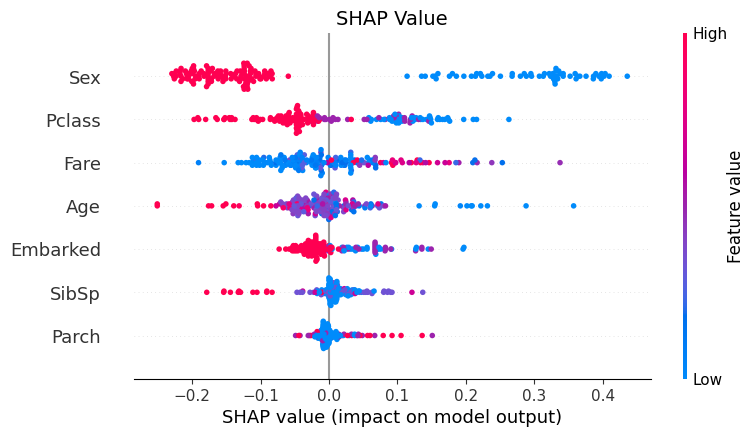

Stacking F1: 0.7286821705426356


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import f1_score

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import optuna
import shap
import matplotlib.pyplot as plt

# 데이터 로드
df = pd.read_csv('titanic.csv')

# 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], errors='ignore')

# 결측치 처리
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 범주형 인코딩
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])

# ★필독! EDA 제안 해줘야 한다.

# X, y
X = df.drop('Survived', axis=1)
y = df['Survived']

# train valid split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)


# ★필독! 모델 선정은 pycaret을 이용해서 스코어 잘나오는 모델 4개 고르기


# Optuna : 하이퍼파라미터 리스트는 구글에 각 모델 검색하면 나온다.
#          (예: 랜덤포레스트 optuna 검색)
def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_lr(trial):
    params = {
        'C': trial.suggest_float('C', 0.01, 10)
    }
    model = LogisticRegression(**params, max_iter=1000)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_svm(trial):
    params = {
        'C': trial.suggest_float('C', 0.1, 10),
        'kernel': trial.suggest_categorical('kernel', ['linear', 'rbf'])
    }
    model = SVC(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_knn(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 15)
    }
    model = KNeighborsClassifier(**params)
    model.fit(X_train, y_train)

    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

# 각 모델마다 옵튜나로 최적의 하이퍼파라미터 탐색
study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10)

study_lr = optuna.create_study(direction='maximize')
study_lr.optimize(objective_lr, n_trials=10)

study_svm = optuna.create_study(direction='maximize')
study_svm.optimize(objective_svm, n_trials=10)

study_knn = optuna.create_study(direction='maximize')
study_knn.optimize(objective_knn, n_trials=10)

# 옵튜나로 찾은 각각 모델의 하이퍼 파라미터로 각각 모델 옵션 정의
rf = RandomForestClassifier(**study_rf.best_params)
lr = LogisticRegression(**study_lr.best_params, max_iter=1000)
svm = SVC(**study_svm.best_params, probability=True)
knn = KNeighborsClassifier(**study_knn.best_params)

# 모델 학습
rf.fit(X_train, y_train)
lr.fit(X_train, y_train)
svm.fit(X_train, y_train)
knn.fit(X_train, y_train)

# 반복문을 통하여 학습이 완료된 모델 꺼내와서 예측하고 f1스코어 출력
for name, model in [('RF', rf), ('LR', lr), ('SVM', svm), ('KNN', knn)]:
    pred = model.predict(X_valid)
    print(name, "F1:", f1_score(y_valid, pred))

# SHAP - 여기서 랜덤포레스트를 지정해서 사후분석 해보겠다.
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_valid)

# 모델마다 SHAP value 행렬 차원이 다르기 때문에 다르게 설정 (수업에서 강조한 내용)
if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

# SHAP  Plot 시각화
shap.summary_plot(
    shap_values, # shape value 반환
    X_valid, # 평가용 데이터로 SHAP value 측정
    feature_names=X.columns, # 컬럼리스트
    plot_type="dot",
    show=False
)
plt.title("SHAP Value", fontsize=14)
plt.show()


# 전방 모델 리스트
est_model_list = [
                      ('rf', rf),
                      ('svm', svm),
                      ('knn', knn)
                  ]


# Stacking 모델 합체
stack = StackingClassifier(
    estimators = est_model_list, # 전방모델
    final_estimator = LogisticRegression() # 후방모델
)

stack.fit(X_train, y_train)

pred = stack.predict(X_valid)
print("Stacking F1:", f1_score(y_valid, pred))

# 전체 코드 하단 작성

## ※ 심플한 코드로는 F1 score가 57정도 나오는 데이터

In [2]:
# 우선 상위 모델 4개를 pycaret으로 먼저 구해보자
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
# 2. 데이터 로드
df = pd.read_csv('Bank Customer Churn Prediction.csv')

# 3. 전처리
# 필요없는 컬럼 제거
df = df.drop(columns=['customer_id'], errors='ignore')

# 범주형 인코딩
le_country = LabelEncoder()
le_gender = LabelEncoder()

df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])
y = df['churn']

# split
(train_df), (valid_df) = train_test_split(df, test_size=0.2, random_state=42, stratify=y) # stratify=y : 'churn'의 비율을 유지하면서 split

from pycaret.classification import *

# PyCaret 설정
clf = setup(
              data          = train_df, # 학습할 데이터프레임 (피처랑 정답 같이 있어야함)
              target        = "churn",
              session_id    = 42,
              verbose       = True
            )

# Step 1. 모든 모델 비교 - F1 기준으로 베스트 모델 선택
best_model = compare_models(sort="F1")

# 모델비교 결과 나오면 4개 확인하고 끝.

,Description,Value
0,Session id,42
1,Target,churn
2,Target type,Binary
3,Original data shape,"(8000, 11)"
4,Transformed data shape,"(8000, 11)"
5,Transformed train set shape,"(5600, 11)"
6,Transformed test set shape,"(2400, 11)"
7,Numeric features,10
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ada,Ada Boost Classifier,0.8555,0.8496,0.4804,0.7197,0.5748,0.4921,0.5074,0.0580
lightgbm,Light Gradient Boosting Machine,0.8559,0.8499,0.4768,0.7237,0.5726,0.4907,0.5073,0.1400
gbc,Gradient Boosting Classifier,0.8614,0.8638,0.4549,0.7735,0.5708,0.4951,0.5209,0.1370
rf,Random Forest Classifier,0.8582,0.8443,0.4436,0.7601,0.5593,0.4820,0.5072,0.1310
et,Extra Trees Classifier,0.8532,0.8424,0.4269,0.7459,0.5418,0.4622,0.4883,0.1000
dt,Decision Tree Classifier,0.7862,0.6777,0.4943,0.4769,0.4849,0.3502,0.3507,0.0140
qda,Quadratic Discriminant Analysis,0.8457,0.8155,0.3243,0.8001,0.4600,0.3887,0.4434,0.0090
lda,Linear Discriminant Analysis,0.8079,0.7611,0.2112,0.5783,0.3086,0.2244,0.2633,0.0130
lr,Logistic Regression,0.8112,0.7433,0.2033,0.6113,0.3043,0.2259,0.2723,0.8620
ridge,Ridge Classifier,0.8038,0.7611,0.0964,0.6202,0.1664,0.1181,0.1863,0.0100


# 데이터 전처리

In [3]:
# 데이터 로드 및 탐색
import pandas as pd
df = pd.read_csv('Bank Customer Churn Prediction.csv')

df.head(1) # 원본데이터 1행 출력

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.0,1,1,1,101348.88,1


In [4]:
df.info() # 결측치 없이 10000행 12 컬럼으로 구성

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       10000 non-null  int64  
 1   credit_score      10000 non-null  int64  
 2   country           10000 non-null  object 
 3   gender            10000 non-null  object 
 4   age               10000 non-null  int64  
 5   tenure            10000 non-null  int64  
 6   balance           10000 non-null  float64
 7   products_number   10000 non-null  int64  
 8   credit_card       10000 non-null  int64  
 9   active_member     10000 non-null  int64  
 10  estimated_salary  10000 non-null  float64
 11  churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(2)
memory usage: 937.6+ KB


In [5]:
# 데이터 전처리 또는 EDA (전처리 기법 왜 그것을 썼는지, 그래프 Draw하고 해석)
# 위의 원본 데이터 1행에서 country와 gender는 범주형으로 이를 라벨인코딩
le_country = LabelEncoder()
le_gender = LabelEncoder()

df['country'] = le_country.fit_transform(df['country'])
df['gender'] = le_gender.fit_transform(df['gender'])
df.drop(columns='customer_id', inplace=True) # churn 예측에 필요없는 컬럼 제거
df.head(1)

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,0,0,42,2,0.0,1,1,1,101348.88,1


In [6]:
# 라벨 인코딩의 각 번호 해석
print("Country Encoding:", dict(zip(le_country.classes_, le_country.transform(le_country.classes_))))
print("Gender Encoding:", dict(zip(le_gender.classes_, le_gender.transform(le_gender.classes_))))

Country Encoding: {'France': 0, 'Germany': 1, 'Spain': 2}
Gender Encoding: {'Female': 0, 'Male': 1}


# EDA 및 해석

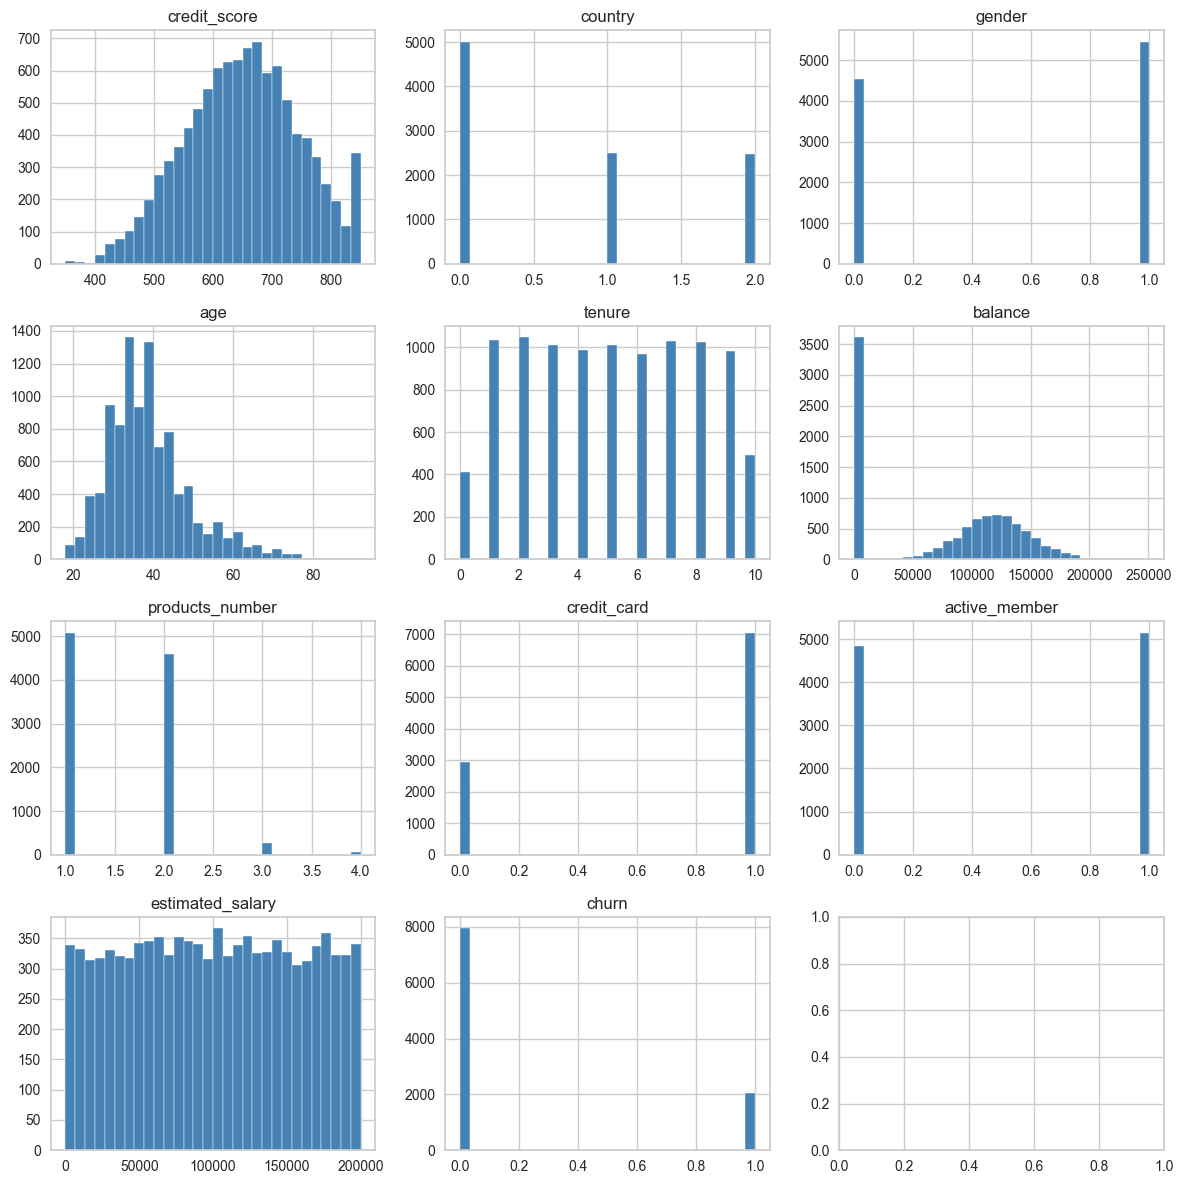

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# 데이터 분포 시각화 (총 11컬럼)
fig, axes = plt.subplots(4, 3, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)

plt.tight_layout()
plt.savefig('distributions.png', dpi=150)
plt.show()

In [ ]:
# 종속변수의 churn은 대략 8:2의 클래스불균형 확인 (모델링 과정에서 반영할 예정)

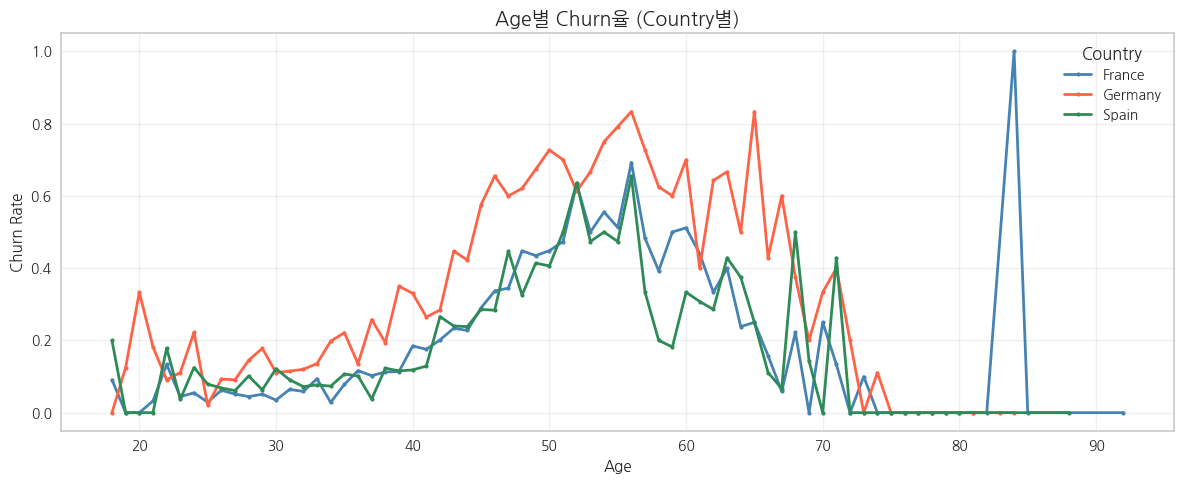

In [27]:
# 꺽은 선 그래프로 나이에 따른 churn의 평균값을 시각화(평균값은 이탈 확률로 해석 가능)
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

country_map = {0: 'France', 1: 'Germany', 2: 'Spain'}  # 인코딩 값에 따라 수정
colors = {0: 'steelblue', 1: 'tomato', 2: 'seagreen'}

plt.figure(figsize=(12, 5))

for country_code, group in df.groupby('country'):
    age_churn = group.groupby('age')['churn'].mean()
    plt.plot(age_churn.index, age_churn.values,
             label=country_map[country_code],
             color=colors[country_code],
             linewidth=2, marker='o', markersize=3)

plt.title('Age별 Churn율 (Country별)', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Churn Rate')
plt.legend(title='Country')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# 꺽은 선 그래프를 보면 나이와 churn의 관계는 20대에서 50대 중반까지는 증가하는 경향을 보지만
# 50대 후반부터는 다시 감소하는 경향이 관찰되었다.
# 각 국가별로 보면 독일은 이탈율이 상대적으로 높아 보이며, 프랑스와 스페인은 유사한 구조로 보인다.
# 프랑스 80~90에서 평균값이 1로 보이는 값은 나이의 이상값으로 예측할 수 있다.
# age의 패턴을 눈여겨 보아, 추가적인 feature selection 과정에 반영한다.

# feature Selection 및 ML 모델 선정 기준

In [11]:
# 다중공선성 제거를 위한 상관관계 분석
df.corr()['churn'] # 상관관계로 독립변수의 선택이 어려우므로 VIF 점수를 확인

credit_score       -0.027094
country             0.035943
gender             -0.106512
age                 0.285323
tenure             -0.014001
balance             0.118533
products_number    -0.047820
credit_card        -0.007138
active_member      -0.156128
estimated_salary    0.012097
churn               1.000000
Name: churn, dtype: float64

In [12]:
# VIF 점수 확인
from statsmodels.stats.outliers_influence import variance_inflation_factor

df_vif = df.drop(columns=['churn']) # 종속변수와 id 컬럼 제거

vif_data = pd.DataFrame()
vif_data['Feature'] = df_vif.columns
vif_data['VIF']     = [variance_inflation_factor(df_vif.values, i)
                        for i in range(df_vif.shape[1])]

# 소수점 2자리, VIF 높은 순 정렬
vif_data['VIF'] = vif_data['VIF'].round(2)
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print(vif_data)

            Feature    VIF
0      credit_score  21.14
1               age  12.33
2   products_number   7.73
3  estimated_salary   3.89
4            tenure   3.87
5       credit_card   3.29
6           balance   2.65
7            gender   2.17
8     active_member   2.07
9           country   1.82


In [13]:
# VIF 점수가 10 이상인 feature는 다중공선성이 높다고 판단
# 따라서 가장 높은 컬럼을 제거하고 다시 VIF 점수 확인
df_vif = df.drop(columns=['churn','credit_score']) # 종속변수와 id 컬럼 제거

vif_data = pd.DataFrame()
vif_data['Feature'] = df_vif.columns
vif_data['VIF']     = [variance_inflation_factor(df_vif.values, i)
                        for i in range(df_vif.shape[1])]

# 소수점 2자리, VIF 높은 순 정렬
vif_data['VIF'] = vif_data['VIF'].round(2)
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print(vif_data) # credit_score 제거 후 VIF 점수 모두 10 이하로 다중공선성 문제 해결

            Feature   VIF
0               age  9.36
1   products_number  6.37
2  estimated_salary  3.72
3            tenure  3.70
4       credit_card  3.17
5           balance  2.48
6            gender  2.12
7     active_member  2.05
8           country  1.80


In [14]:
df.drop(columns=['credit_score'], inplace=True) # 모델링 과정에서도 제거된 컬럼으로 진행
df.head(1)

,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,0,0,42,2,0.0,1,1,1,101348.88,1


In [15]:
# 다음 모델링 과정에서 churn을 제외한 컬럼을 X로, churn을 y로 설정하여 모델링 진행
X = df.drop('churn', axis=1)
y = df['churn']

In [16]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# 클래스 불균형을 해결하기 위한 stratify=y 옵션을 사용

In [17]:
# "churn" 컬럼을 분류하는 모델 성능 테스트 결과(pycaret 이용)
# f1 score 기준 상위 4 모델 ada, light, gbc, rf (각 모델은 성능 55점 이상으로 다음 모델을 사용)

# 상위모델 4개 고른 것을, 각 모델 optuna로 최적의 파라미터 찾기
# (옵션 리스트는 구글 검색 필요 할 것)
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import AdaBoostClassifier

def objective_ada(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500)
    }
    model = AdaBoostClassifier(**params, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_light(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12)
    }
    model = LGBMClassifier(**params, random_state=42, verbose=-1)
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_gbc(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10)
    }
    model = GradientBoostingClassifier(**params, random_state=42)
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 20)
    }
    model = RandomForestClassifier(**params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    pred = model.predict(X_valid)
    return f1_score(y_valid, pred)

study_ada = optuna.create_study(direction='maximize')
study_ada.optimize(objective_ada, n_trials=10)

study_light = optuna.create_study(direction='maximize')
study_light.optimize(objective_light, n_trials=10)

study_gbc = optuna.create_study(direction='maximize')
study_gbc.optimize(objective_gbc, n_trials=10)

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=10)

ada   = AdaBoostClassifier(**study_ada.best_params, random_state=42)
light = LGBMClassifier(**study_light.best_params, random_state=42, verbose=-1)
gbc   = GradientBoostingClassifier(**study_gbc.best_params, random_state=42)
rf    = RandomForestClassifier(**study_rf.best_params, random_state=42, n_jobs=-1)

ada.fit(X_train, y_train)
light.fit(X_train, y_train)
gbc.fit(X_train, y_train)
rf.fit(X_train, y_train)

for name, model in [('AdaBoost', ada), ('LightGBM', light), ('GBC', gbc), ('RF', rf)]:
    pred = model.predict(X_valid)
    print(name, "F1:", f1_score(y_valid, pred))

[I 2026-04-09 17:08:29,482] A new study created in memory with name: no-name-af30babf-0d01-4293-b880-62b49dbaaf77
[I 2026-04-09 17:08:30,266] Trial 0 finished with value: 0.5777126099706745 and parameters: {'n_estimators': 159}. Best is trial 0 with value: 0.5777126099706745.
[I 2026-04-09 17:08:31,403] Trial 1 finished with value: 0.5811209439528023 and parameters: {'n_estimators': 222}. Best is trial 1 with value: 0.5811209439528023.
[I 2026-04-09 17:08:32,606] Trial 2 finished with value: 0.5790251107828656 and parameters: {'n_estimators': 240}. Best is trial 1 with value: 0.5811209439528023.
[I 2026-04-09 17:08:33,644] Trial 3 finished with value: 0.5781710914454278 and parameters: {'n_estimators': 212}. Best is trial 1 with value: 0.5811209439528023.
[I 2026-04-09 17:08:34,519] Trial 4 finished with value: 0.5797950219619327 and parameters: {'n_estimators': 183}. Best is trial 1 with value: 0.5811209439528023.
[I 2026-04-09 17:08:36,981] Trial 5 finished with value: 0.572271386430

AdaBoost F1: 0.5811209439528023
LightGBM F1: 0.593974175035868
GBC F1: 0.6081694402420574
RF F1: 0.5797546012269938


In [ ]:
# AdaBoost F1: 0.5811209439528023
# LightGBM F1: 0.593974175035868
# GBC F1: 0.6081694402420574
# RF F1: 0.5797546012269938

# 모델 성능은 GBC > LightGBM > AdaBoost > RF 순으로 기존 모델링(고객id 제거)보다 1~3점정도 향상되어 출력되었다.
# 모델 성능이 가장 좋은 GBC로 SHAP value 시각화 진행

# SHAP value 사후분석과 인사이트 제안

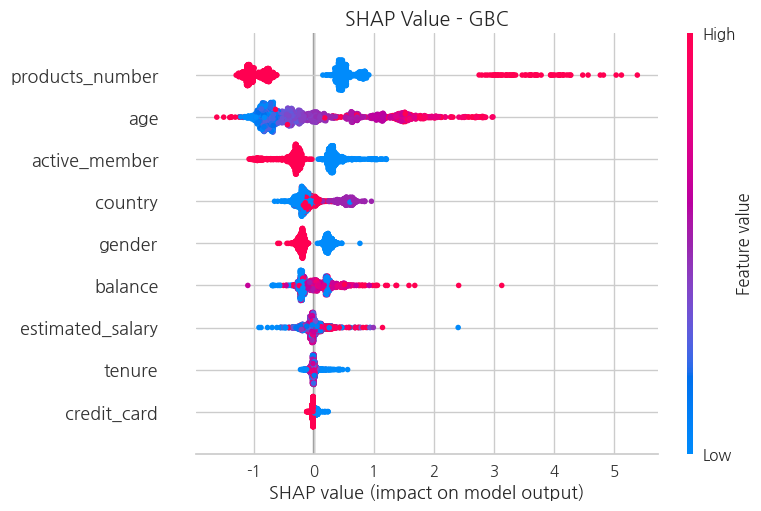

In [28]:
# 모델 4개 중 1개 잡아서 SHAP Value 시각화 하기 (교재 내용 적용 요망, 도움 요청 가능)
# SHAP - GBC로 사후분석
explainer = shap.TreeExplainer(gbc)
shap_values = explainer.shap_values(X_valid)

if isinstance(shap_values, list):
    shap_values = shap_values[1]
elif shap_values.ndim == 3:
    shap_values = shap_values[:, :, 1]
else:
    shap_values = shap_values

shap.summary_plot(
    shap_values,
    X_valid,
    feature_names=X.columns,
    plot_type="dot",
    show=False
)
plt.title("SHAP Value - GBC", fontsize=14)
plt.show()

In [20]:
# SHAP value 시각화 결과
# 이용중인 상품이 많으면 이탈확률이 대체로 낮아지지만 높은 영향을 미치기도 한다. (분포상 소수이기 때문에, 고령고객의 사망으로 추측)
# 나이가 적은 경우 이탈율에 음의 영향을 보이며, 연령이 높아질 수록 이탈율에 양의 영향을 미치는 경향이 강하다.
# 비활성 고객의 경우 이탈율에 양의 영향을 미치는 경향이 확실하다.
# 잔액의 붉은 색이 우측의 분포하는 경향을 보이지만, 모호하다.
# 성별에 차이도 보이지만, 영향이 크지 않다.
# country의 0, 1, 2로 각각 프랑스, 독일, 스페인으로 인코딩 되어 있기 때문에 독일은 양의 영향, 프랑스는 음의영향을 준다.
# 나머지 컬럼은 영향력이 적거나 해석이 모호하므로 생략한다.

# 인사이트
# EDA에서 age와 churn의 관계를 꺽은선 그래프로 시각화 했을 때 50대 후반부터는 다시 감소하는 경향이 관찰되었다.
# SHAP value 시각화 결과에서는 EDA 상 보이지 않았던 고령일수록 이탈율에 양의 영향력을 확인할 수 있었다.
# 50~60대의 적은 종류의 상품을 이용하는 고객을 타겟
# 타겟을 대상으로 신규 상품 가입 시 우대 금리를 적용하는 등의 활성고객 유도가 필요하다.
# 시범운영 국가를 선정한다면 독일을 선택한다.

# Stacking 모델링 및 Validation 점수 출력

In [26]:
# 4개 모델을 Stacking (전방모델, 후방모델 아무거나) f1스코어 혹은 accuracy 스코어를 출력하기 57정도 나올 듯
est_model_list = [
    ('rf', rf),
    ('gbc', gbc),
    ('light', light)
]

stack = StackingClassifier(
    estimators=est_model_list,
    final_estimator=ada # 후방 모델로 ada 선택
)

stack.fit(X_train, y_train)
pred = stack.predict(X_valid)

# validation score 출력하기
print("Stacking F1:", f1_score(y_valid, pred))

# Stacking F1: 0.5967016491754122

Stacking F1: 0.5967016491754122


In [ ]:
# 기존 모델링 성능(optuna 기반 하이퍼파라미터 튜닝 모델)
# AdaBoost F1: 0.5811209439528023
# LightGBM F1: 0.593974175035868
# GBC F1: 0.6081694402420574
# RF F1: 0.5797546012269938

# 스택킹 모델의 전방/후방 모델을 교차적으로 선택한 결과 ada를 후방모델로 했을 때 성능이 가장 높게 나왔지만,
# 기존 GBC 모델 보다 성능이 낮게 나왔다. 따라서 스택킹 모델을 적용할 때 또한 좋은 모델을 다 넣기 보다는 적절한 모델을 선택할 필요가 있다.
# 또한 영향력이 낮은 변수를 제거하여 새롭게 모델링을 진행하는 것도 성능 향상에 도움이 될 수 있다.